# 🏨 Hotel Booking Cancellation Prediction using Machine Learning

This project focuses on analyzing hotel booking data to understand the key factors that influence booking cancellations. Using a comprehensive dataset containing information such as lead time, price (ADR), customer type, and booking details, exploratory data analysis (EDA) is performed to identify patterns and trends related to customer behavior.

The project further applies machine learning techniques to predict whether a booking is likely to be canceled. Various classification models such as Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Naive Bayes are implemented and evaluated using performance metrics like accuracy, precision, recall, F1-score, and ROC-AUC.

The results help in identifying the most important features affecting booking cancellations and selecting the best-performing model. This study demonstrates how data-driven approaches can be used to improve decision-making in the hospitality industry and reduce cancellation risks.

# 🎯 Objectives of the Study
- To analyze the hotel booking dataset and understand its structure and key features
- To perform data cleaning and preprocessing, including handling missing values and removing irrelevant columns
- To explore relationships between features such as lead time, ADR (price), and customer type using visualization techniques
- To analyze booking patterns and identify factors affecting cancellation behavior
- To build and train multiple machine learning models for classification of booking cancellations
- To evaluate and compare model performance using metrics like accuracy, precision, recall, F1-score, and ROC-AUC
- To identify the most important features influencing booking cancellations
- To select the best-performing model for predicting whether a booking will be canceled or not

# Libraries

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

# Load Dataset

In [3]:
df = pd.read_csv("hotel_booking.csv")

# Basic Info

In [49]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [50]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 119389 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119389 non-null  object 
 1   is_canceled                     119389 non-null  int64  
 2   lead_time                       119389 non-null  int64  
 3   arrival_date_year               119389 non-null  int64  
 4   arrival_date_month              119389 non-null  object 
 5   arrival_date_week_number        119389 non-null  int64  
 6   arrival_date_day_of_month       119389 non-null  int64  
 7   stays_in_weekend_nights         119389 non-null  int64  
 8   stays_in_week_nights            119389 non-null  int64  
 9   adults                          119389 non-null  int64  
 10  children                        119389 non-null  float64
 11  babies                          119389 non-null  int64  
 12  meal                 

In [51]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000,119389.000000
mean,0.370419,104.010654,2016.156547,27.165317,15.798332,0.927573,2.500272,1.856402,0.103887,0.007949,0.031904,0.087119,0.137081,0.221109,74.826659,2.321169,101.832028,0.062518,0.571368
std,0.482919,106.863220,0.707475,13.605105,8.780811,0.998578,1.908267,0.579263,0.398557,0.097437,0.175746,0.844340,1.497433,0.652288,107.140867,17.594793,50.535032,0.245292,0.792800
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,94.590000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000


# Data Cleaning

In [13]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)

### 📖 Explanation:
- In this step, missing values in the dataset are handled to ensure data quality. The 'children' column is filled with 0, assuming that missing values indicate no children. The 'country' column is filled with the most frequent value (mode), as it is a categorical feature. The 'agent' column is filled with 0, indicating that no agent was involved in the booking. Handling missing values is essential to prevent errors during model training and improve accuracy.

In [ ]:
df.drop(['company'], axis=1, inplace=True)

### 📖 Explanation:
- The 'company' column is removed because it contains a large number of missing values, making it unreliable for analysis.

In [16]:
df = df[df['adr'] >= 0]

In [18]:
df = df.drop(['name', 'email', 'phone-number', 'credit_card'], axis=1)

### 📖 Explanation:
- Columns containing personal information are removed as they do not contribute to prediction and may introduce noise.

In [20]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [21]:
print(df.shape)
print(df.isnull().sum())

(119389, 31)
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_pa

In [19]:
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

# EDA(Graphs Section)

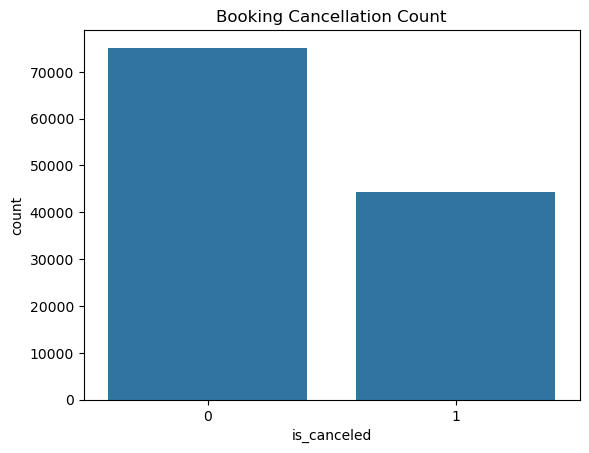

In [23]:
sns.countplot(x='is_canceled', data=df)
plt.title("Booking Cancellation Count")
plt.show()

### 📖 Explanation:

This graph represents the count of hotel bookings that were canceled and not canceled. The x-axis shows the cancellation status, where 0 indicates not canceled and 1 indicates canceled bookings. The y-axis shows the total number of bookings in each category. It can be observed that the number of non-canceled bookings is higher than canceled ones, indicating an imbalance in the dataset.

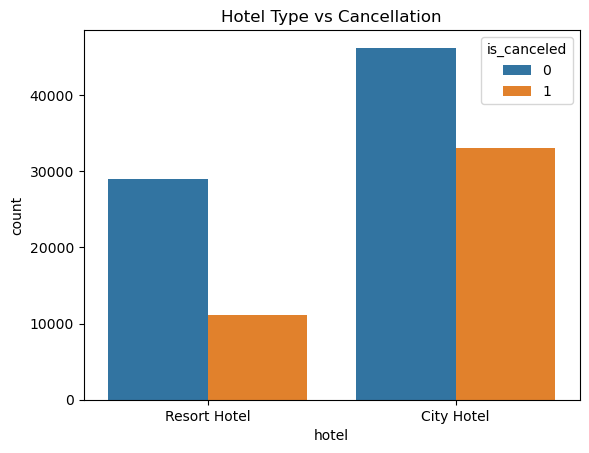

In [24]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title("Hotel Type vs Cancellation")
plt.show()

### 📖 Explanation:

This graph shows the relationship between hotel type and booking cancellation. The x-axis represents the type of hotel (Resort Hotel and City Hotel), while the y-axis shows the number of bookings. The bars are divided based on cancellation status, where 0 indicates not canceled and 1 indicates canceled bookings. It can be observed that City Hotels have a higher number of bookings as well as a higher number of cancellations compared to Resort Hotels.

### 🔍 Insight:

City Hotels experience more cancellations than Resort Hotels, indicating that customers booking City Hotels are more likely to cancel.

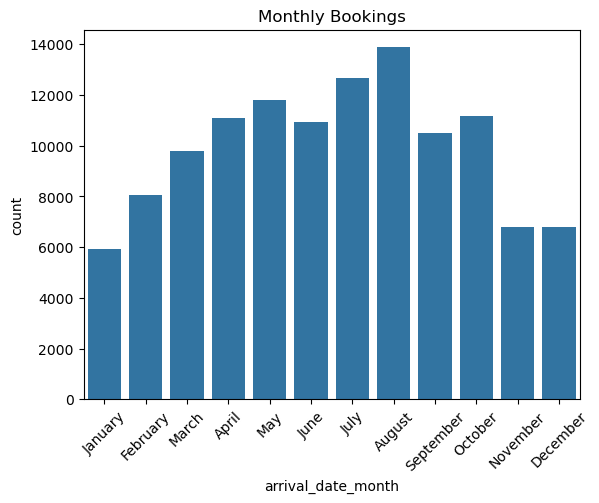

In [25]:
sns.countplot(x='arrival_date_month', data=df,
              order=['January','February','March','April','May','June',
                     'July','August','September','October','November','December'])

plt.xticks(rotation=45)
plt.title("Monthly Bookings")
plt.show()

### 📖 Explanation:

This graph shows the number of hotel bookings across different months. The x-axis represents the months of the year, while the y-axis shows the total number of bookings. It can be observed that bookings gradually increase from the beginning of the year and peak around the summer months, especially in July and August. After that, bookings start to decline towards the end of the year.

### 🔍 Insight:

Hotel bookings are highest during the summer season (July and August), indicating peak demand during holidays, while bookings are lower in winter months like January and December.

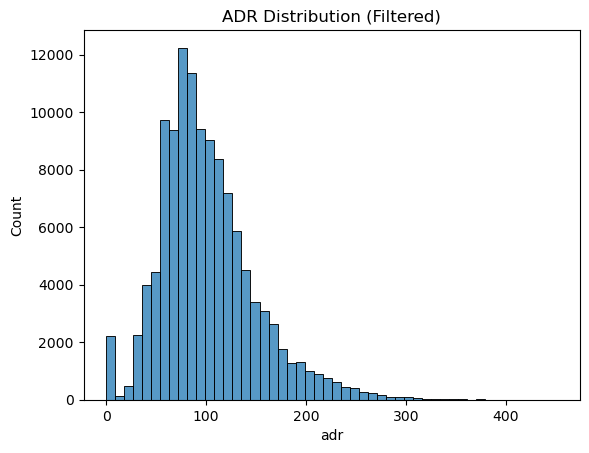

In [ ]:
df_adr = df[df['adr'] < 500] 

sns.histplot(df_adr['adr'], bins=50)
plt.title("ADR Distribution (Filtered)")
plt.show()

### 📖 Explanation:

This graph shows the distribution of the Average Daily Rate (ADR), which represents the price per night for hotel bookings. The x-axis represents the ADR values, while the y-axis shows the frequency of bookings within each price range. Outliers have been removed to focus on realistic pricing. It can be observed that most bookings fall within the mid-price range, approximately between 50 and 150.

### 🔍 Insight:

Most hotel bookings are concentrated in the moderate price range, indicating that customers prefer mid-range pricing over very low or very high prices.

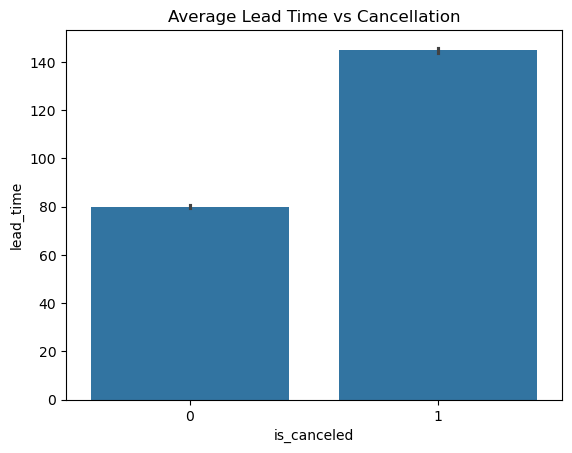

In [69]:
sns.barplot(x='is_canceled', y='lead_time', data=df)
plt.title("Average Lead Time vs Cancellation")
plt.show()

### 📖 Explanation:

This graph shows the relationship between lead time and booking cancellation. The x-axis represents the cancellation status (0 = not canceled, 1 = canceled), while the y-axis shows the average lead time. It can be observed that bookings that were canceled have a higher average lead time compared to those that were not canceled.

### 🔍 Insight:

Bookings made earlier (higher lead time) are more likely to be canceled compared to bookings made closer to the check-in date.

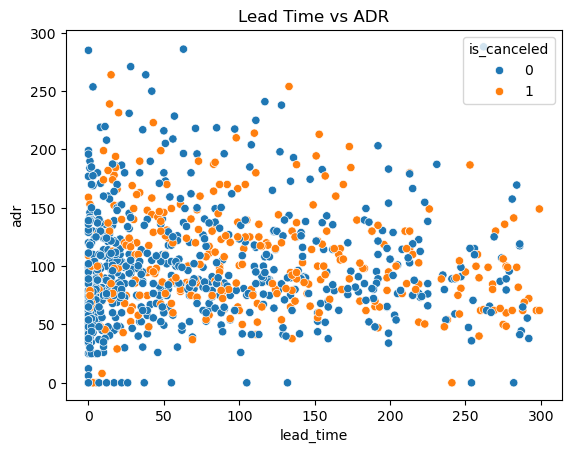

In [97]:
sns.scatterplot(x='lead_time', y='adr', hue='is_canceled', data=df_sample)
plt.title("Lead Time vs ADR")
plt.show()

### 📖 Explanation:

This scatter plot shows the relationship between lead time and average daily rate (ADR). The x-axis represents the lead time (number of days before booking), while the y-axis represents the price per night (ADR). The points are colored based on cancellation status, where 0 indicates not canceled and 1 indicates canceled bookings. It can be observed that there is no strong correlation between lead time and price, as the data points are widely scattered.

### 🔍 Insight:

Cancellations occur across all price ranges, indicating that price alone does not determine booking cancellations. However, bookings with higher lead time show slightly more cancellations.

# Preprocessing

In [29]:
X = X.drop(['reservation_status', 'reservation_status_date'], axis=1)

### 📖 Explanation:

In this step, unnecessary columns such as `reservation_status` and `reservation_status_date` are removed from the dataset. These columns are directly related to the target variable (`is_canceled`) and may cause data leakage. Removing them ensures that the model learns from independent features only, improving the reliability of predictions.

In [31]:
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

### 📖 Explanation:

Machine learning models cannot process categorical (text) data directly. Therefore, categorical features such as hotel type, meal, and market segment are converted into numerical form using Label Encoding. Each unique category is assigned a numeric value, allowing the model to interpret and learn patterns from the data.

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

### 📖 Explanation:

The dataset is divided into training and testing sets using the train-test split method. The training set (80%) is used to train the machine learning models, while the testing set (20%) is used to evaluate their performance. This helps in assessing how well the model generalizes to unseen data.

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 📖 Explanation:

Feature scaling is applied using StandardScaler to normalize the data. This process transforms the features so that they have a mean of 0 and a standard deviation of 1. Scaling ensures that all features contribute equally to the model, especially for algorithms like KNN and Logistic Regression that are sensitive to feature magnitude.

# ML Models

### 📖 K-Nearest Neighbors (KNN):

KNN is a distance-based algorithm that classifies a data point based on the majority class of its nearest neighbors. It calculates the distance between data points (usually Euclidean distance) and assigns the class accordingly. In this project, KNN is used to compare performance with other models, though it may be sensitive to scaling and data distribution.

In [104]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(Y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_knn))

KNN Accuracy: 0.8361253036267694
Confusion Matrix:
 [[13149  1778]
 [ 2135  6816]]


### 📖 Logistic Regression:

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability of a class (0 or 1) using a sigmoid function. In this project, it is used to classify whether a booking will be canceled or not. It performs well when there is a linear relationship between features and the target variable.

In [105]:
lr = LogisticRegression(max_iter=5000 , solver='liblinear')
lr.fit(X_train, Y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(Y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7941619901164252
Confusion Matrix:
 [[13740  1187]
 [ 3728  5223]]


### 📖 Naive Bayes:

Naive Bayes is a probabilistic machine learning algorithm based on Bayes’ Theorem. It assumes that all features are independent of each other, which is why it is called “naive.” Despite this assumption, it performs well in many real-world classification problems.

In this project, Naive Bayes is used to predict whether a booking will be canceled or not. It is fast, efficient, and works well with large datasets, but its performance may be limited when features are highly correlated.

In [106]:
nb = GaussianNB()
nb.fit(X_train, Y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(Y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_nb))

Naive Bayes Accuracy: 0.47340648295502136
Confusion Matrix:
 [[ 2553 12374]
 [  200  8751]]


### 📖 Decision Tree:

Decision Tree is a tree-based algorithm that splits the dataset into branches based on feature values. Each node represents a decision rule, and each leaf node represents an outcome. It is easy to understand and interpret. In this project, it helps identify key decision paths that lead to booking cancellations.

In [107]:
dt = DecisionTreeClassifier()
dt.fit(X_train, Y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(Y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_dt))

Decision Tree Accuracy: 0.8555992964234861
Confusion Matrix:
 [[13187  1740]
 [ 1708  7243]]


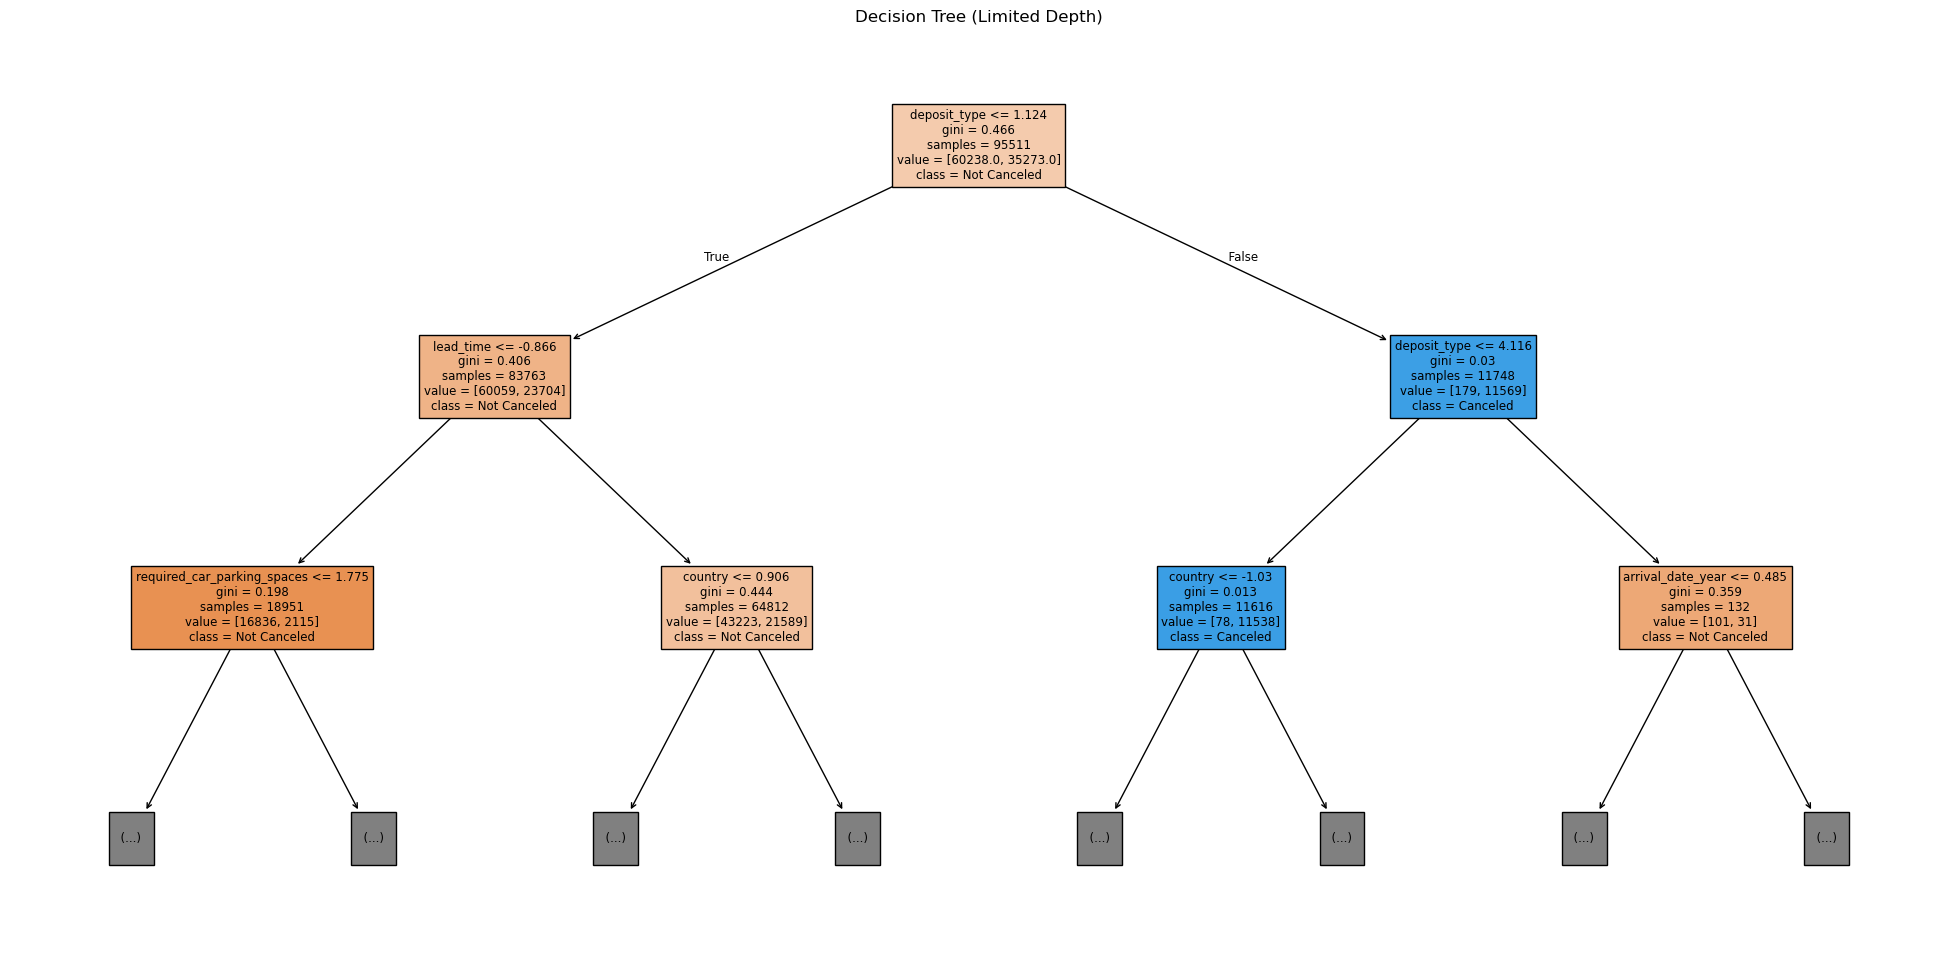

In [108]:
plt.figure(figsize=(25,12))
plot_tree(dt, filled=True, max_depth=2,
          feature_names=X.columns,
          class_names=['Not Canceled','Canceled'])
plt.title("Decision Tree (Limited Depth)")
plt.show()

### 📖 Random Forest:

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve accuracy and reduce overfitting. It uses bagging (bootstrap sampling) and random feature selection to create diverse trees. In this project, Random Forest provides the best performance by capturing complex patterns in booking data and making robust predictions.

In [109]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, Y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_rf))

Random Forest Accuracy: 0.8940866069185024
Confusion Matrix:
 [[14022   905]
 [ 1624  7327]]


# Evaluation

### 📊 Model Evaluation:

The performance of all models is evaluated using metrics such as Accuracy, Precision, Recall, and F1-score. Accuracy measures overall correctness, Precision indicates how many predicted cancellations were correct, Recall shows how many actual cancellations were identified, and F1-score provides a balance between Precision and Recall. Additionally, ROC-AUC is used to evaluate the model's ability to distinguish between classes.

In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = []

# KNN
metrics.append([
    "KNN",
    accuracy_score(Y_test, y_pred_knn),
    precision_score(Y_test, y_pred_knn),
    recall_score(Y_test, y_pred_knn),
    f1_score(Y_test, y_pred_knn)
])

# Logistic Regression
metrics.append([
    "Logistic Regression",
    accuracy_score(Y_test, y_pred_lr),
    precision_score(Y_test, y_pred_lr),
    recall_score(Y_test, y_pred_lr),
    f1_score(Y_test, y_pred_lr)
])

# Naive Bayes
metrics.append([
    "Naive Bayes",
    accuracy_score(Y_test, y_pred_nb),
    precision_score(Y_test, y_pred_nb),
    recall_score(Y_test, y_pred_nb),
    f1_score(Y_test, y_pred_nb)
])

# Decision Tree
metrics.append([
    "Decision Tree",
    accuracy_score(Y_test, y_pred_dt),
    precision_score(Y_test, y_pred_dt),
    recall_score(Y_test, y_pred_dt),
    f1_score(Y_test, y_pred_dt)
])

# Random Forest
metrics.append([
    "Random Forest",
    accuracy_score(Y_test, y_pred_rf),
    precision_score(Y_test, y_pred_rf),
    recall_score(Y_test, y_pred_rf),
    f1_score(Y_test, y_pred_rf)
])

In [111]:
metrics_df = pd.DataFrame(metrics, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  KNN  0.836125   0.793111  0.761479  0.776973
1  Logistic Regression  0.794162   0.814821  0.583510  0.680034
2          Naive Bayes  0.473406   0.414249  0.977656  0.581926
3        Decision Tree  0.855599   0.806301  0.809183  0.807739
4        Random Forest  0.894087   0.890063  0.818568  0.852820


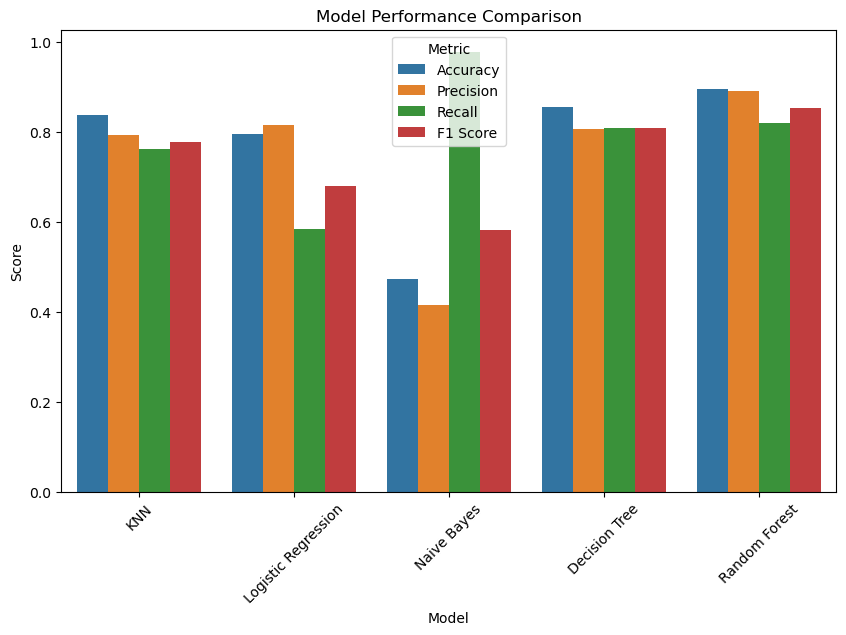

In [112]:
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Score", hue="Metric", data=metrics_melted)

plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

# Model Comparison

### 🏆 Best Model Selection:

Among all the models, Random Forest achieved the highest accuracy and overall performance. Therefore, it is selected as the best model for predicting hotel booking cancellations. Its ability to handle complex patterns and reduce overfitting makes it the most reliable choice for this problem.

In [113]:
results = {
    "KNN": accuracy_score(Y_test, y_pred_knn),
    "Logistic Regression": accuracy_score(Y_test, y_pred_lr),
    "Naive Bayes": accuracy_score(Y_test, y_pred_nb),
    "Decision Tree": accuracy_score(Y_test, y_pred_dt),
    "Random Forest": accuracy_score(Y_test, y_pred_rf)
}

print(results)

{'KNN': 0.8361253036267694, 'Logistic Regression': 0.7941619901164252, 'Naive Bayes': 0.47340648295502136, 'Decision Tree': 0.8555992964234861, 'Random Forest': 0.8940866069185024}


In [114]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0                  KNN  0.836125
1  Logistic Regression  0.794162
2          Naive Bayes  0.473406
3        Decision Tree  0.855599
4        Random Forest  0.894087


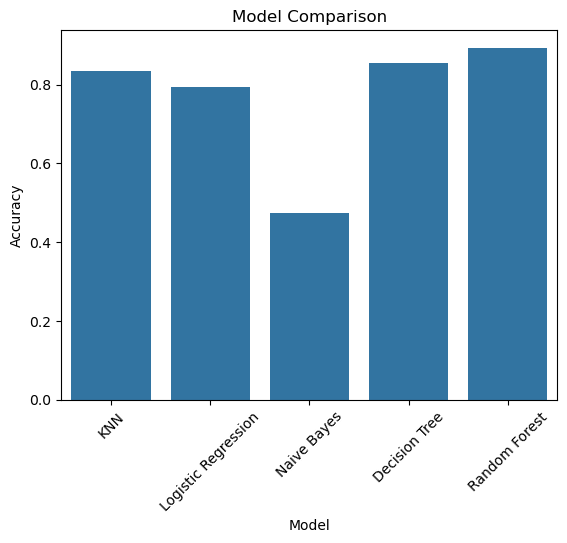

In [115]:
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.show()

# ROC Curve(Random Forest)

### 📖 Explanation:

The ROC (Receiver Operating Characteristic) curve is used to evaluate the performance of the Random Forest model. It plots the True Positive Rate (Recall) against the False Positive Rate at different threshold values.

The AUC (Area Under the Curve) score for this model is approximately 0.96, which indicates excellent performance. A value close to 1 means the model can effectively distinguish between canceled and non-canceled bookings.

The curve is positioned near the top-left corner, showing high true positive rates and low false positive rates, which confirms that the model is highly accurate and reliable.

The high AUC score indicates that the model has strong discriminative power and is suitable for real-world prediction tasks.

In [116]:
y_prob = rf.predict_proba(X_test)[:, 1]

In [117]:
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

In [118]:
roc_auc = auc(fpr, tpr)
print("AUC Score:", roc_auc)

AUC Score: 0.9609144909651054


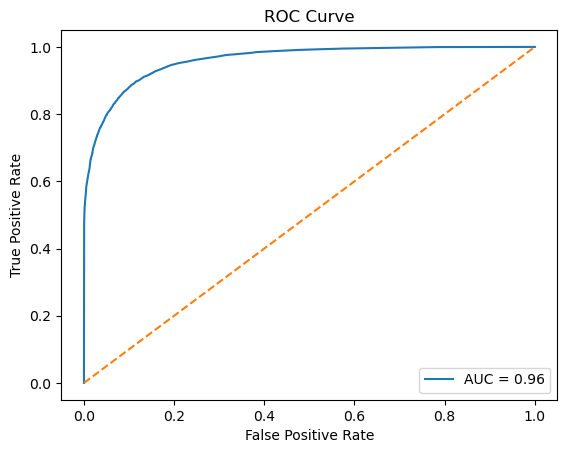

In [119]:
plt.figure()

plt.plot(fpr, tpr, label="AUC = {:.2f}".format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [134]:
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(best_model_name)

Random Forest


In [136]:
if best_model_name == "Logistic Regression":
    best_model = model_lr
elif best_model_name == "Decision Tree":
    best_model = model_dt
elif best_model_name == "Random Forest":
    best_model = rf
elif best_model_name == "KNN":
    best_model = model_knn

print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


# Feature Importance

### 📖 Explanation:

Feature importance is used to identify which input features have the most influence on the model’s predictions. In this step, the Random Forest model is used to extract importance scores for each feature.

Each feature is assigned a numerical value that represents how much it contributes to predicting whether a booking will be canceled or not. Higher values indicate more important features.

The features are then sorted in descending order to highlight the most significant ones. Finally, a bar chart is plotted to visually display the top important features.

This helps in understanding the key factors affecting booking cancellation and improves model interpretability.

In [131]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance.head(10))

deposit_type                 0.130362
lead_time                    0.122819
country                      0.112584
adr                          0.072733
total_of_special_requests    0.055990
agent                        0.055167
arrival_date_day_of_month    0.052883
arrival_date_week_number     0.049345
market_segment               0.046961
stays_in_week_nights         0.034332
dtype: float64


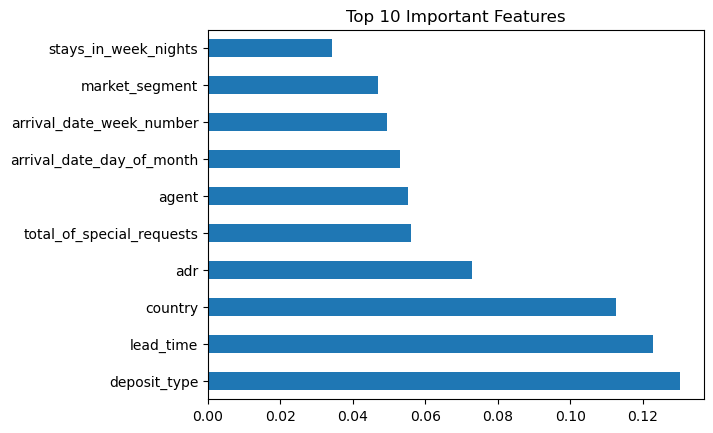

In [132]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

# Prediction

In [133]:
comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": y_pred
})
print(comparison.head(10))

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       0          0
5       0          1
6       1          1
7       0          0
8       0          0
9       0          0


In [137]:
new_data = X_test[0].reshape(1, -1)
prediction = best_model.predict(new_data)
print("Prediction:", prediction)

Prediction: [0]


## 📌 Conclusion

In this project, machine learning techniques were successfully applied to analyze hotel booking data and predict booking cancellations. The dataset was preprocessed by handling missing values, encoding categorical variables, and selecting relevant features.

Exploratory Data Analysis (EDA) helped in identifying important patterns, such as the impact of lead time, price (ADR), and deposit type on booking cancellations. Visualizations provided clear insights into customer behavior and booking trends.

Multiple classification models, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Naive Bayes, were implemented and evaluated using performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

Among all models, Random Forest achieved the best performance, indicating its ability to handle complex patterns and feature interactions effectively.

Overall, the project demonstrates how machine learning can be used to predict booking cancellations and assist businesses in making data-driven decisions.

## 🚀 Future Scope

This project can be further improved and extended in several ways:

- Use advanced machine learning models such as XGBoost, LightGBM, or deep learning techniques to improve prediction accuracy.
- Perform hyperparameter tuning to optimize model performance.
- Handle class imbalance using techniques like SMOTE or class weighting.
- Deploy the model as a web application using Flask or Streamlit for real-time predictions.
- Integrate real-time booking data for dynamic and continuous prediction.
- Include additional features such as customer reviews, seasonal trends, and external factors to enhance model performance.
- Apply feature selection techniques to further improve efficiency and reduce model complexity.

These improvements can make the system more robust, scalable, and suitable for real-world applications.